In [1]:
# --- EXPERIMENTAL DATA PLOTTING PIPELINE ---
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set global parameters for publication-quality plots
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.linewidth': 1.5,
    'lines.linewidth': 2.0,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'legend.frameon': True,
    'legend.edgecolor': 'black'
})

print("Generating Experimental Figures...")


Generating Experimental Figures...


Saved: 'Figure_Galvanostatic.png'


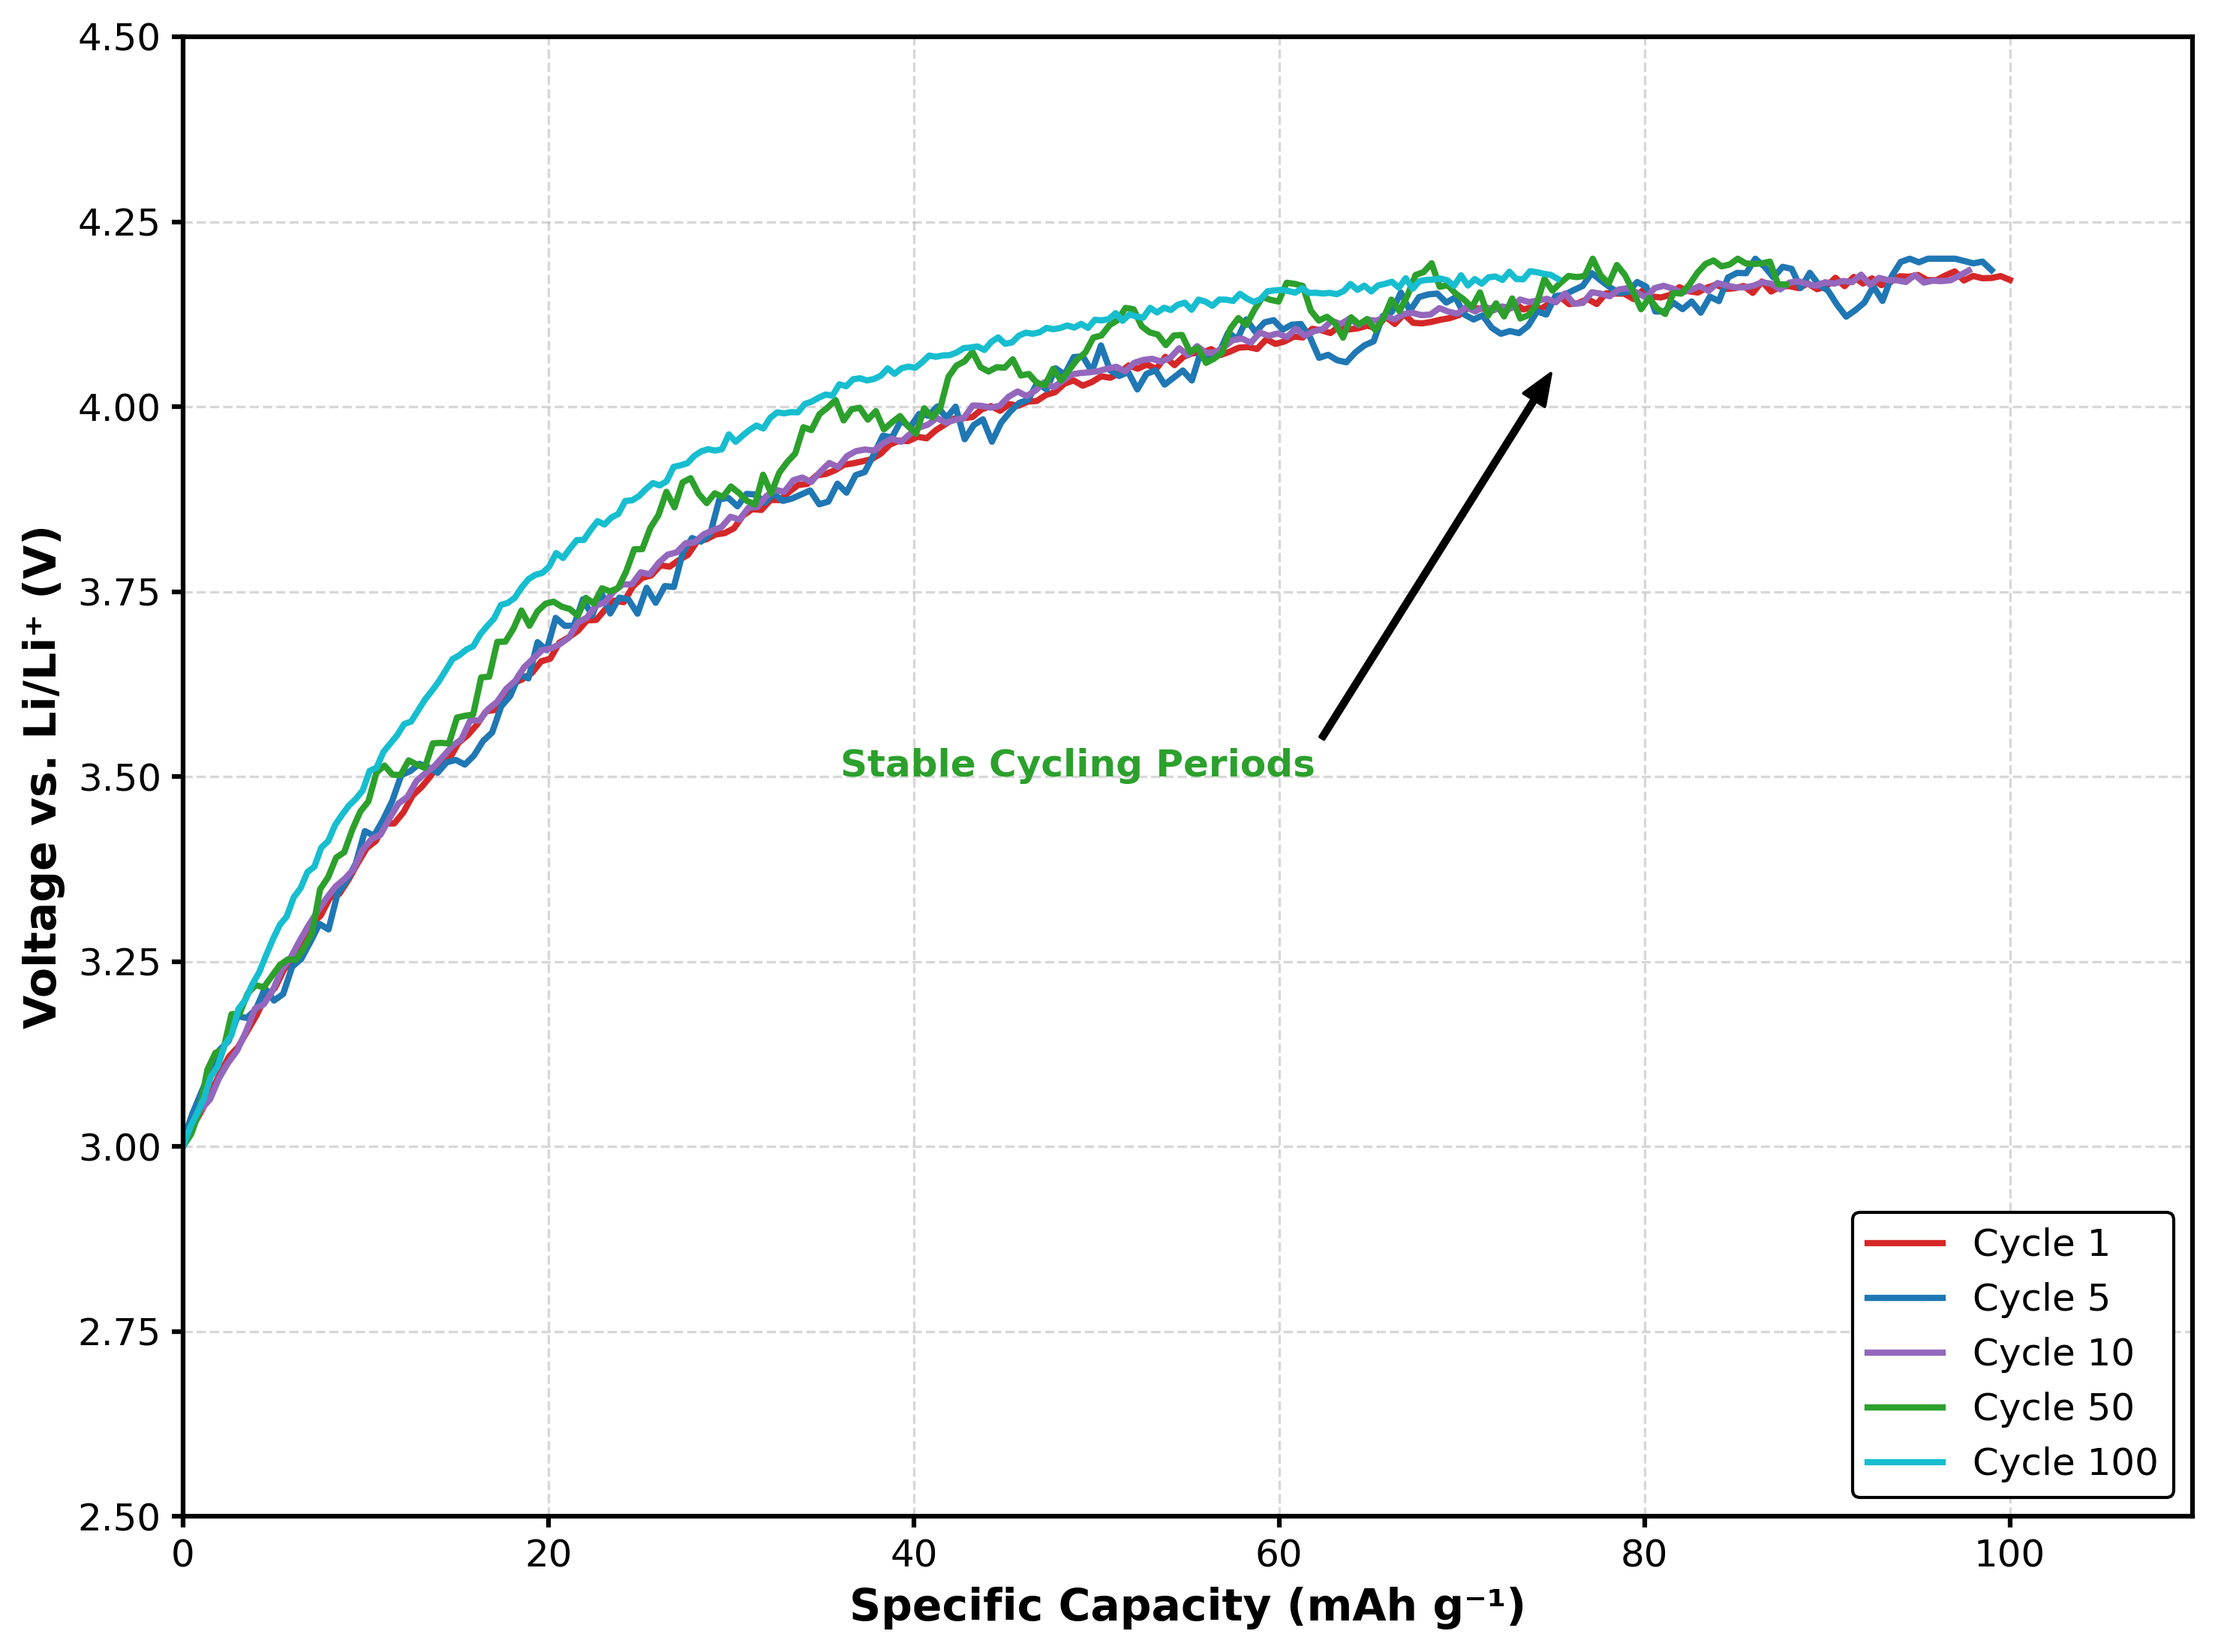

In [2]:
# FIGURE 2: Galvanostatic Cycling
# ---------------------------------------------------------
galv_file = 'PEO_NMC622_60C_Galvanostatic_100cyc.csv'

try:
    df_galv = pd.read_csv(galv_file)
    
    fig, ax = plt.subplots(figsize=(10, 7.5), dpi=300)
    
    # Specific cycles and colors
    cycles_to_plot = [1, 5, 10, 50, 100]
    colors = ['#d62728', '#1f77b4', '#9467bd', '#2ca02c', '#17becf'] # Red, Blue, Purple, Green, Cyan
    
    for cycle, col in zip(cycles_to_plot, colors):
        cycle_data = df_galv[df_galv['Cycle_Number'] == cycle]
        if not cycle_data.empty:
            ax.plot(cycle_data['Capacity_mAh'], cycle_data['Voltage_V'], 
                    label=f'Cycle {cycle}', color=col, linewidth=2)
            
    # Axis labels
    ax.set_xlabel('Specific Capacity (mAh g⁻¹)', fontweight='bold', fontsize=14)
    ax.set_ylabel('Voltage vs. Li/Li⁺ (V)', fontweight='bold', fontsize=14)
    
    # Axis limits
    ax.set_xlim(0, 110)
    ax.set_ylim(2.50, 4.50)
    
    # Grid styling
    ax.grid(linestyle='--', alpha=0.5)
    
    # Annotation 
    ax.annotate('Stable Cycling Periods', 
                xy=(75, 4.05), xycoords='data', # Where the arrow points
                xytext=(36, 3.50), textcoords='data', # Where the text starts
                arrowprops=dict(facecolor='black', width=1.5, headwidth=8, headlength=10, shrink=0.01),
                fontsize=12, fontweight='bold', color='#2ca02c')
    
    # Legend styling and placement
    ax.legend(loc='lower right', framealpha=1.0, edgecolor='black', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('Figure_Galvanostatic.png', dpi=300, bbox_inches='tight')
    print("Saved: 'Figure_Galvanostatic.png'")
    plt.show()

except FileNotFoundError:
    print(f"Skipping Figure: Could not find '{galv_file}'. Please check the filename.")

Saved: 'Figure_Nyquist.png'


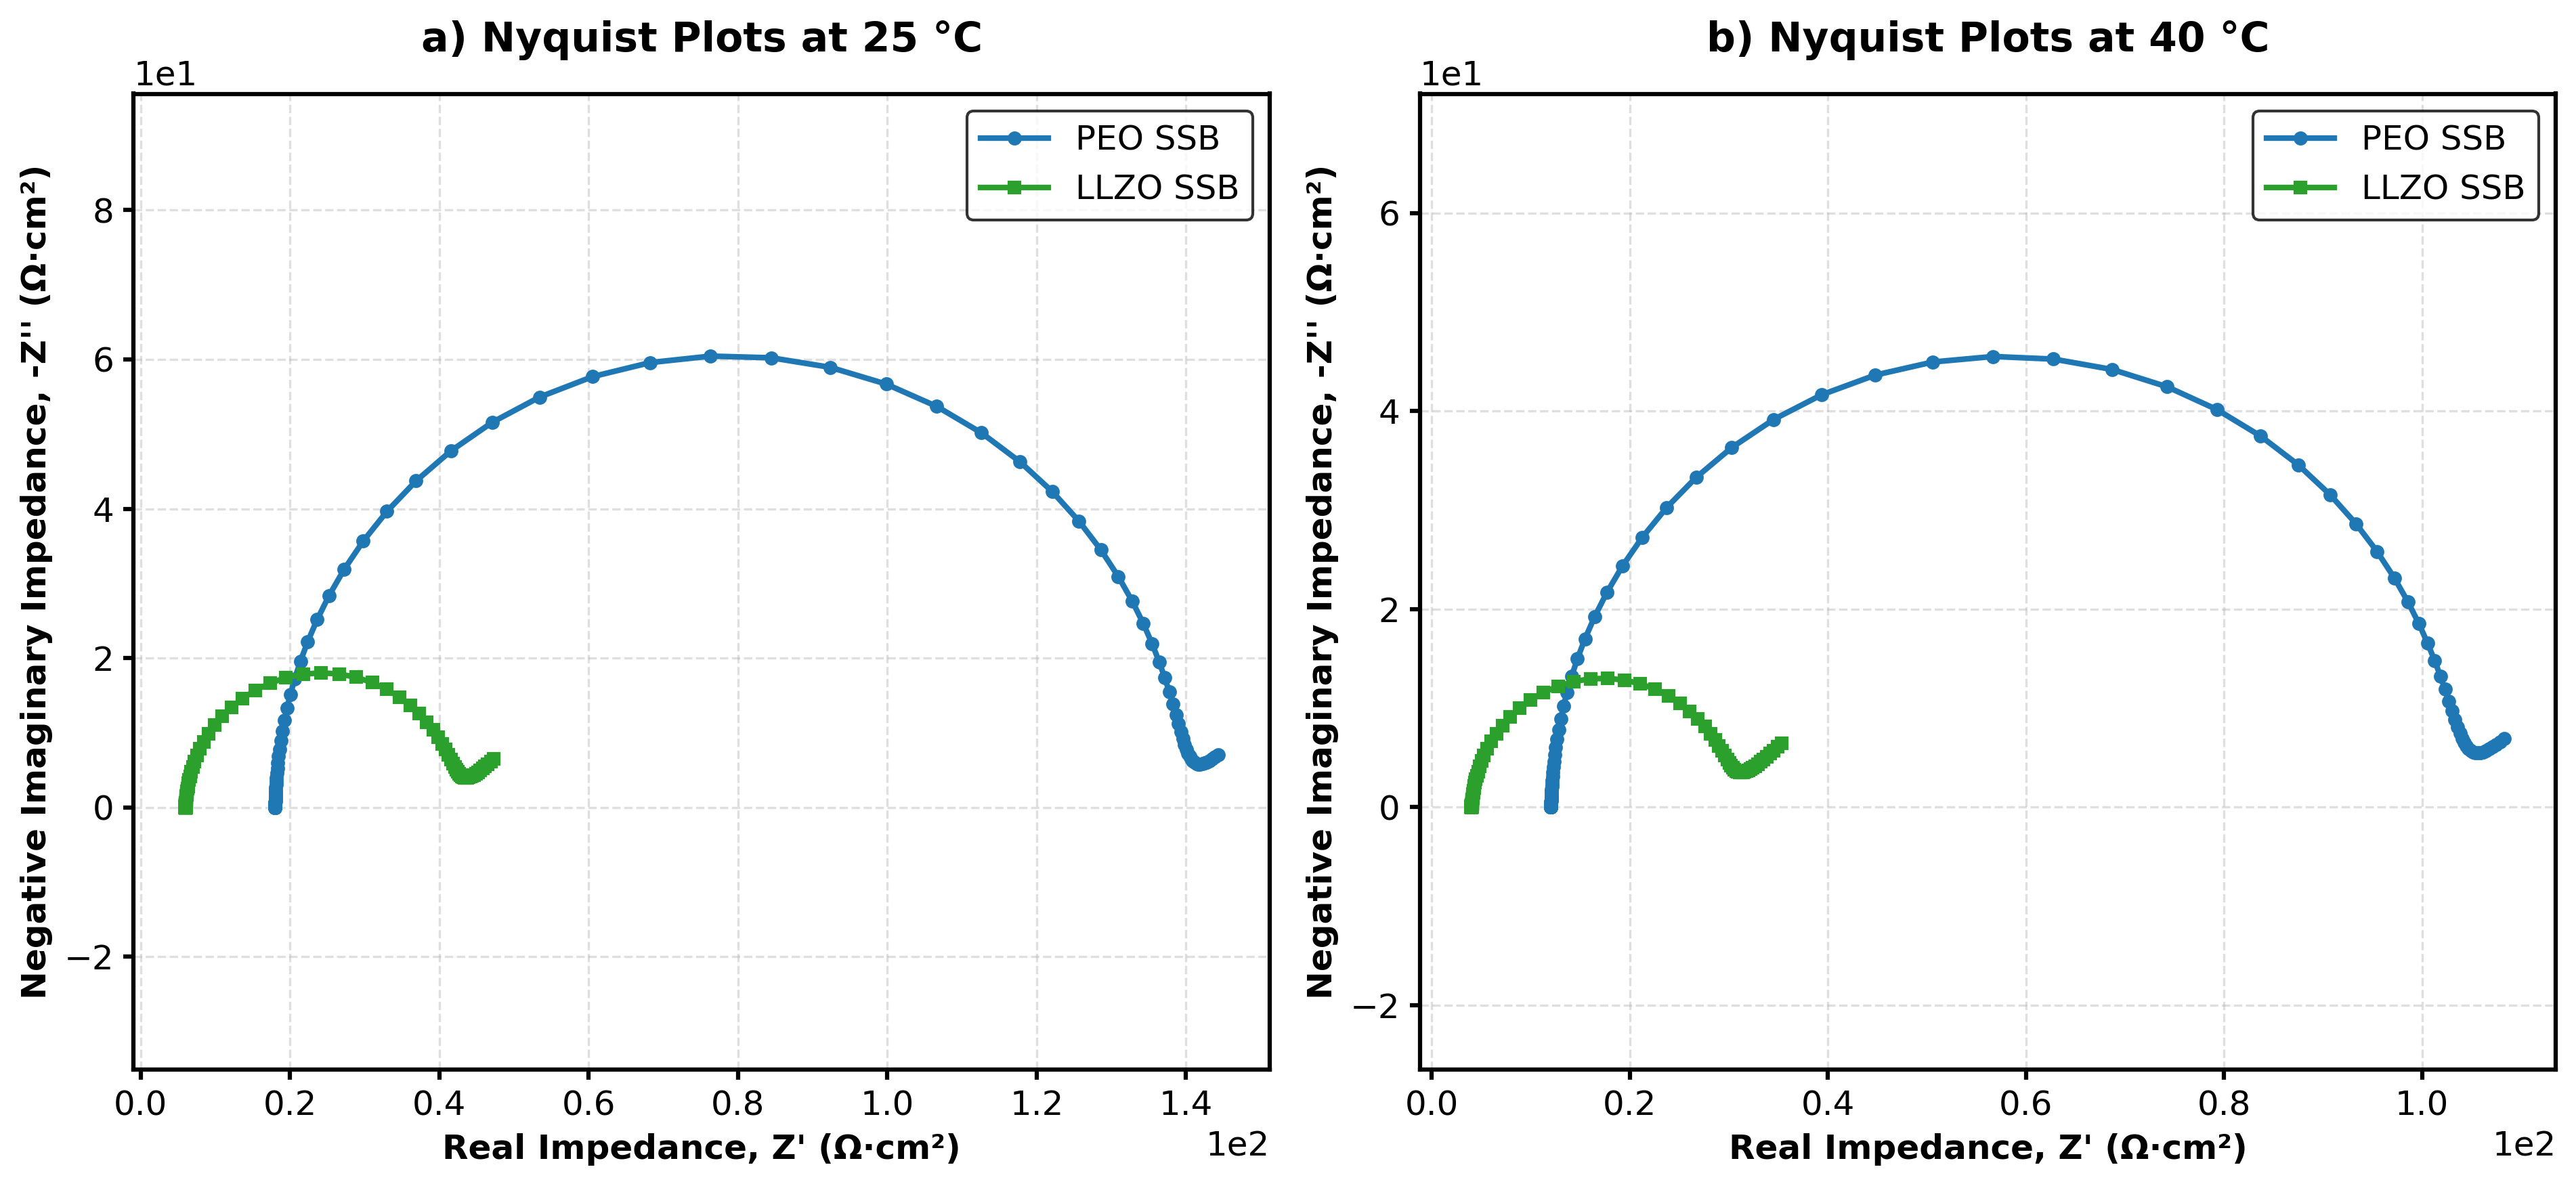

In [3]:
# FIGURE 4: Nyquist Plots (Dual Panel) - Updated Axes & Colors
# ---------------------------------------------------------
try:
    df_peo_25 = pd.read_csv('PEO_EIS_25C.csv')
    df_llzo_25 = pd.read_csv('LLZO_Nyquist_25C.csv')
    df_peo_40 = pd.read_csv('PEO_EIS_40C.csv')
    df_llzo_40 = pd.read_csv('LLZO_Nyquist_40C.csv')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), dpi=300)

    # Standard Journal Colors (Blue and Green)
    color_peo = '#1f77b4'
    color_llzo = '#2ca02c'

    # Panel a: 25°C
    ax1.plot(df_peo_25['Z_real_Ohm'], -df_peo_25['Z_imag_Ohm'], 
             'o-', markersize=4, label='PEO SSB', color=color_peo, linewidth=2)
    ax1.plot(df_llzo_25['Z_real_Ohm'], -df_llzo_25['Z_imag_Ohm'], 
             's-', markersize=4, label='LLZO SSB', color=color_llzo, linewidth=2)
    
    ax1.set_title('a) Nyquist Plots at 25 °C', fontweight='bold', pad=15)
    ax1.set_xlabel("Real Impedance, Z' (Ω·cm²)", fontweight='bold')
    ax1.set_ylabel("Negative Imaginary Impedance, -Z'' (Ω·cm²)", fontweight='bold')
    ax1.legend()
    ax1.grid(linestyle='--', alpha=0.4)
    ax1.set_aspect('equal', adjustable='datalim')
    
    # Scientific notation (1e2) on the axes
    ax1.ticklabel_format(style='sci', axis='both', scilimits=(0,0)) 

    # Panel b: 40°C
    ax2.plot(df_peo_40['Z_real_Ohm'], -df_peo_40['Z_imag_Ohm'], 
             'o-', markersize=4, label='PEO SSB', color=color_peo, linewidth=2)
    ax2.plot(df_llzo_40['Z_real_Ohm'], -df_llzo_40['Z_imag_Ohm'], 
             's-', markersize=4, label='LLZO SSB', color=color_llzo, linewidth=2)
    
    ax2.set_title('b) Nyquist Plots at 40 °C', fontweight='bold', pad=15)
    ax2.set_xlabel("Real Impedance, Z' (Ω·cm²)", fontweight='bold')
    ax2.set_ylabel("Negative Imaginary Impedance, -Z'' (Ω·cm²)", fontweight='bold')
    ax2.legend()
    ax2.grid(linestyle='--', alpha=0.4)
    ax2.set_aspect('equal', adjustable='datalim')
    
    #Scientific notation (1e2) on the axes
    ax2.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

    plt.tight_layout()
    plt.savefig('Figure_Nyquist.png', dpi=300, bbox_inches='tight')
    print("Saved: 'Figure_Nyquist.png'")
    plt.show()

except FileNotFoundError as e:
    print(f"Skipping Figure: Missing EIS files. Details: {e}")

Saved: 'Figure_Optimization.png'


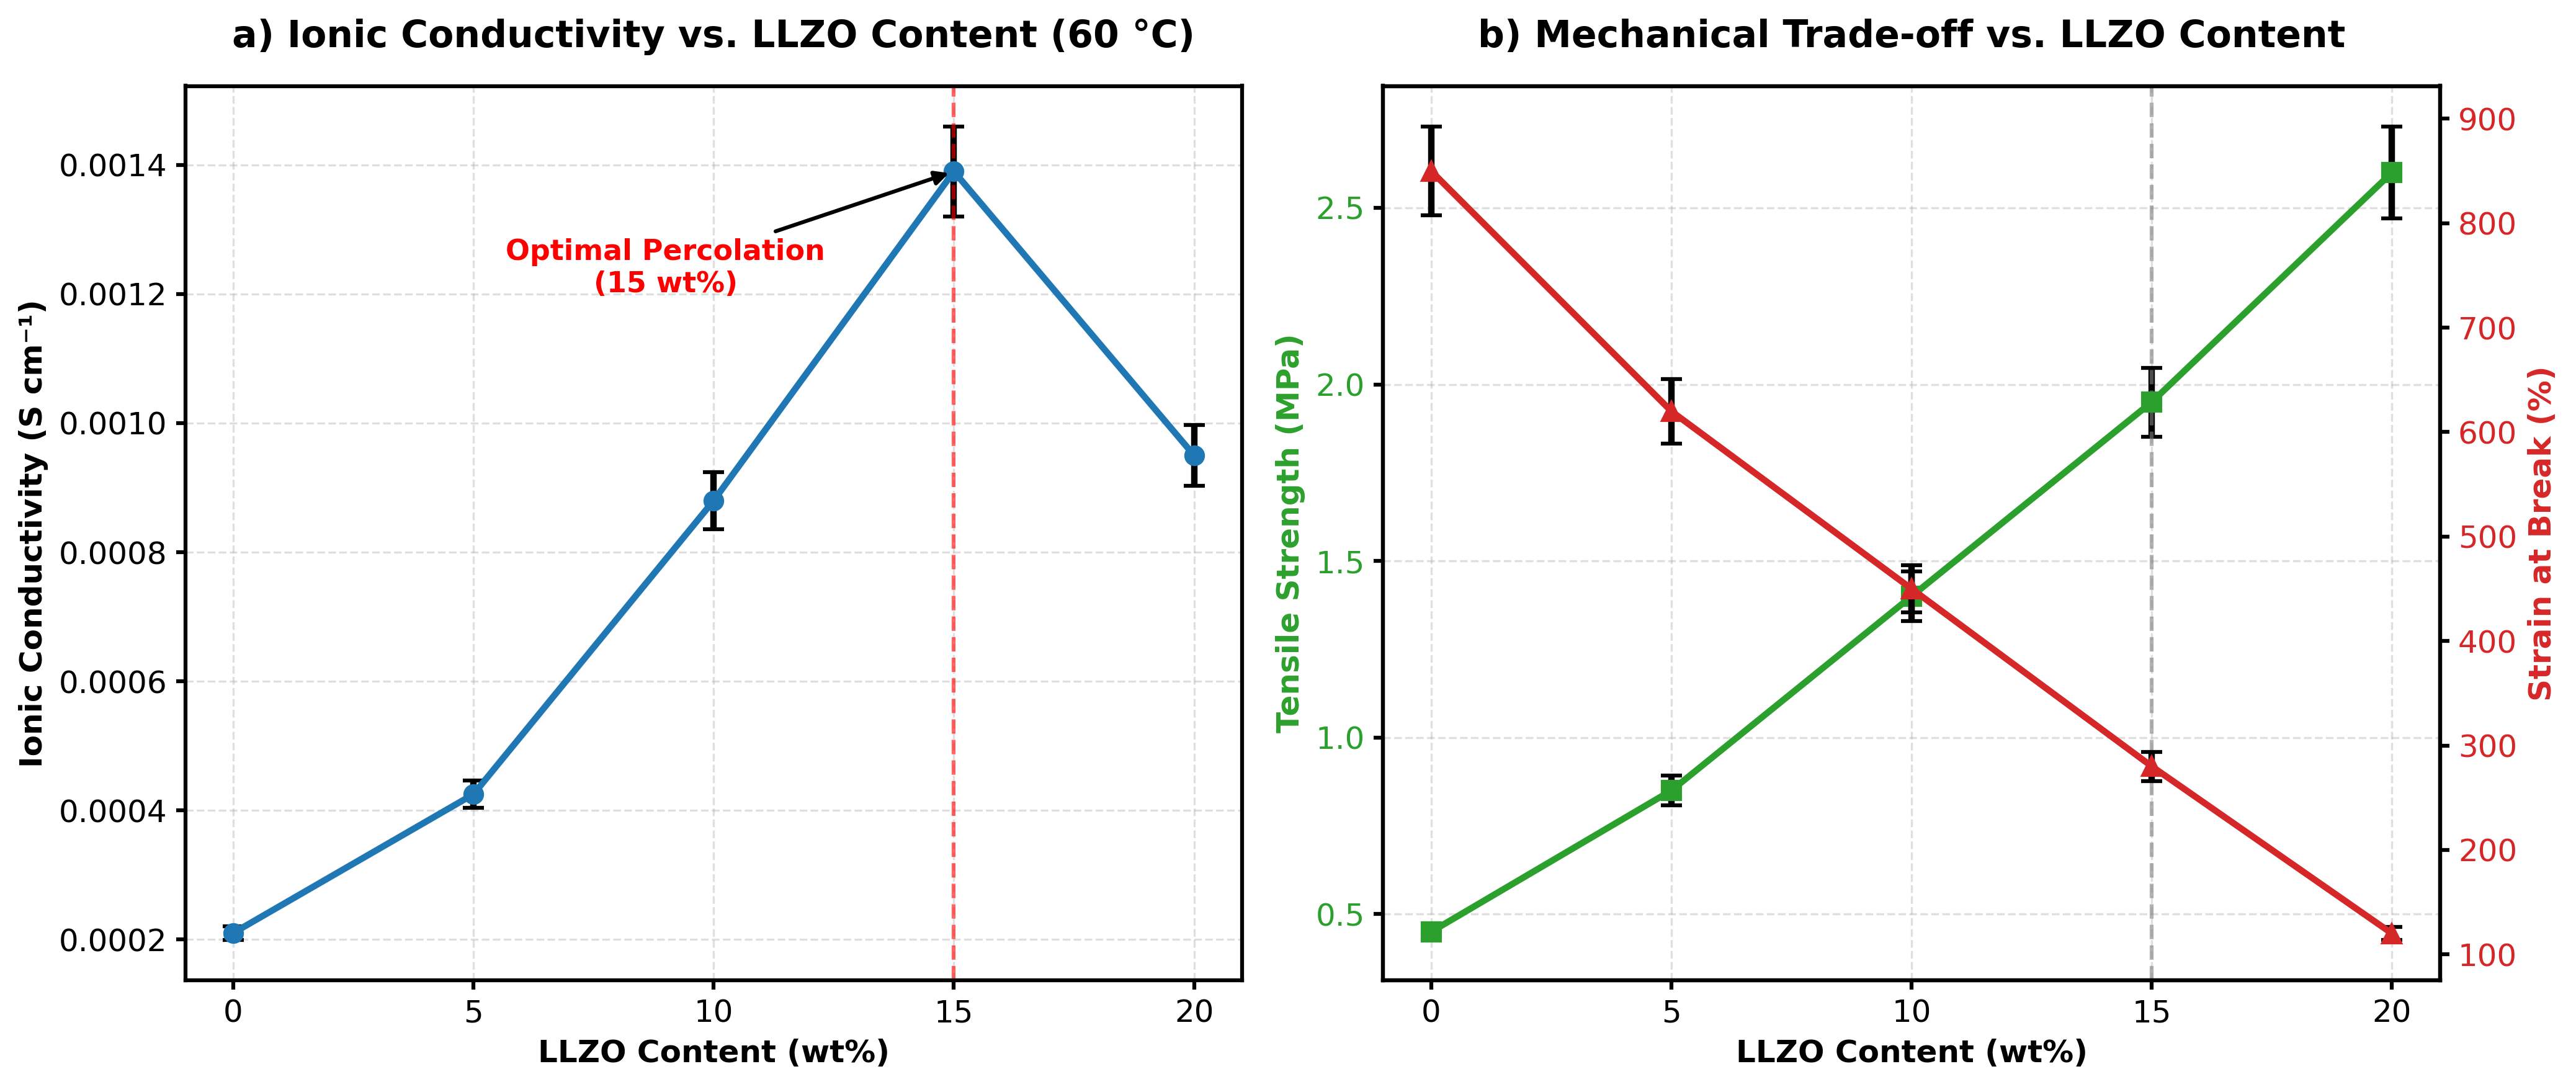

In [4]:
# FIGURE 5: Composite Optimization with Error Bars (Exact Image Match)
# ---------------------------------------------------------
try:
    df_cond = pd.read_csv('Conductivity_Optimization_Data.csv')
    df_mech = pd.read_csv('Mechanical_Tensile_Optimization.csv')

    # Create a dual-panel figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

    yerr_cond = df_cond['Conductivity_StdDev'] if 'Conductivity_StdDev' in df_cond.columns else df_cond['Ionic_Conductivity_S_cm'] * 0.05 
    yerr_ts = df_mech['Tensile_StdDev'] if 'Tensile_StdDev' in df_mech.columns else df_mech['Tensile_Strength_MPa'] * 0.05
    yerr_strain = df_mech['Strain_StdDev'] if 'Strain_StdDev' in df_mech.columns else df_mech['Strain_at_Break_percent'] * 0.05

    # Panel a: Electrochemical Response
    ax1.errorbar(df_cond['LLZO_Content_wt%'], df_cond['Ionic_Conductivity_S_cm'], 
                 yerr=yerr_cond, fmt='o-', markersize=7, color='#1f77b4', 
                 linewidth=2.5, capsize=4, capthick=1.5, ecolor='black')
    
    ax1.axvline(x=15, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
    
    peak_idx = df_cond['Ionic_Conductivity_S_cm'].idxmax()
    peak_x = df_cond['LLZO_Content_wt%'][peak_idx]
    peak_y = df_cond['Ionic_Conductivity_S_cm'][peak_idx]
    
    ax1.annotate('Optimal Percolation\n(15 wt%)', 
                 xy=(peak_x, peak_y), xycoords='data',
                 xytext=(peak_x - 6, peak_y - 0.00015), textcoords='data', # Offsets the text to the bottom left of the peak
                 arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5),
                 ha='center', va='center', color='red', fontweight='bold', fontsize=11)
    
    ax1.set_title('a) Ionic Conductivity vs. LLZO Content (60 °C)', fontweight='bold', pad=15)
    ax1.set_xlabel('LLZO Content (wt%)', fontweight='bold')
    ax1.set_ylabel('Ionic Conductivity (S cm⁻¹)', fontweight='bold')
    ax1.set_xticks(df_cond['LLZO_Content_wt%'])
    ax1.grid(linestyle='--', alpha=0.4)

    # Panel b: Mechanical Trade-offs
    color_ts = '#2ca02c' # Green
    color_sab = '#d62728' # Red
    
    ax2.set_title('b) Mechanical Trade-off vs. LLZO Content', fontweight='bold', pad=15)
    ax2.set_xlabel('LLZO Content (wt%)', fontweight='bold')
    
    # Primary y-axis (ax2): Tensile Strength (Green Squares)
    ax2.set_ylabel('Tensile Strength (MPa)', color=color_ts, fontweight='bold')
    ax2.errorbar(df_mech['LLZO_Content_wt%'], df_mech['Tensile_Strength_MPa'], 
                 yerr=yerr_ts, fmt='s-', markersize=7, color=color_ts, 
                 linewidth=2.5, capsize=4, capthick=1.5, ecolor='black')
    ax2.tick_params(axis='y', labelcolor=color_ts)
    ax2.set_xticks(df_mech['LLZO_Content_wt%'])
    ax2.grid(linestyle='--', alpha=0.4)
    
    ax2.axvline(x=15, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)

    ax3 = ax2.twinx()
    ax3.set_ylabel('Strain at Break (%)', color=color_sab, fontweight='bold')
    ax3.errorbar(df_mech['LLZO_Content_wt%'], df_mech['Strain_at_Break_percent'], 
                 yerr=yerr_strain, fmt='^-', markersize=7, color=color_sab, 
                 linewidth=2.5, capsize=4, capthick=1.5, ecolor='black')
    ax3.tick_params(axis='y', labelcolor=color_sab)

    plt.tight_layout()
    plt.savefig('Figure_Optimization.png', dpi=300, bbox_inches='tight')
    print("Saved: 'Figure_Optimization.png'")
    plt.show()

except FileNotFoundError:
    print("Skipping Figure: Missing Optimization CSV files. Please check filenames.")